In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
os.environ["KERAS_BACKEND"] = "torch"

In [10]:
df = pd.read_csv('../datasets/fashion_mnist/fashion-mnist_train.csv')
x_train = df.drop('label', axis=1)
y_train = df['label']

df = pd.read_csv('../datasets/fashion_mnist/fashion-mnist_test.csv')
x_test = df.drop('label', axis=1)
y_test = df['label']

x_train.head(2)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
y_train.head(2)

0    2
1    9
Name: label, dtype: int64

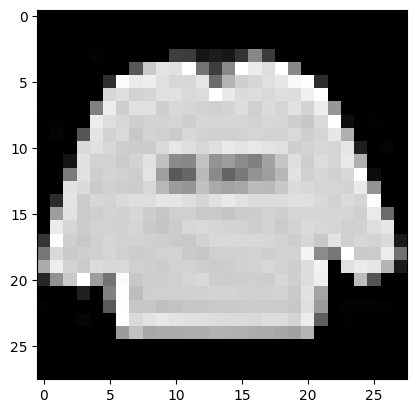

In [3]:
zz = x_train.values[0].reshape(28, 28)
plt.imshow(zz, cmap='gray')
plt.show()

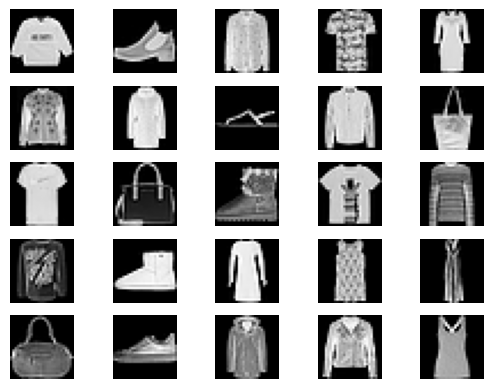

In [4]:
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train.values[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

In [11]:
# https://keras.io/getting_started/intro_to_keras_for_engineers/

#(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 784)
y_train shape: (60000,)
60000 train samples
10000 test samples


## Convolutional Network 

<img src="figures/conv1.png" width="300"/>


### Input / Output

* The input of the network is (28, 28, 1), not (28, 28). This is a choice of the library to accomodate for multiple bands.

* The output is Dense(num_classes, activation="softmax") so node *i* outputs the probability of class *i*

### Inner Layers

* **Conv2D(64, kernel_size=(3, 3)** There are 64 filters 3*3 each. 

<img src="figures/conv1_1.png" width="200"/>

Each filter has (3 * 3 * num_bands + 1) paramters (1 is for the bias). Therefore in this case, num_bands = 1, so 10 paramter for each filter. There are 64 filter, 640 parameters in total.
The input of this layer is (28, 28, 1) but the output of each filter is (26, 26, 64) because the first 2 pixels are outside of the filter margin, 64 bands for 64 filters.
(there could be the padding='same' option)

* **Conv2D(64, kernel_size=(3, 3)** Other 64 filters 3 * 3 each. 64 * (3 * 3 * num_band + 1). This time, num_bands = 64.
So 64 * (3 * 3 * 64 + 1) = 36'928 paramteres.
The output is (24, 24, 64).
Note when a filer is applied to a multi-band data, the convolutions of different bands are summed together.
This is why we end up having again a 64 bands output (otherwise we would have 64 * 64 badds)

* **MaxPooling2D(pool_size=(2, 2))** MaxPooling2D reduces the feature map size from (24, 24) to (12, 12) by taking the maximum value in each 2×2 window (for each band).
This layers is not trained, 0 parametersm and te output is (12, 12, 64)

<img src="figures/max_pooling.png" width="200"/>


* **Conv2D(128, kernel_size=(3, 3)** Other 128 filters 3*3 each. 128 * (3 * 3 * 64 + 1) = 73'856 parameters.
The output is (10, 10, 128)

* **Conv2D(128, kernel_size=(3, 3)** Other 128 filters 3*3 each. 128 * (3 * 3 * 128 + 1) = 147'584 parameters.
The output is (8, 8, 128)


* **GlobalAveragePooling2D()** computes the average of each feature map across its entire spatial dimensions.
The output is (1,128)

* **Dropout(0.5)** randomly sets a fraction (50%) of neurons to zero during training. 

* **Dense(num_classes, activation="softmax")** receives 128 inputs and outputs num_classes probabilities



In [12]:
num_classes = 10
input_shape = (28, 28, 1)



model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_classes, activation="softmax"),
    ]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,298 (1016.79 KB)

 Trainable params: 260,298 (1016.79 KB)

 Non-trainable params: 0 (0.00 B)

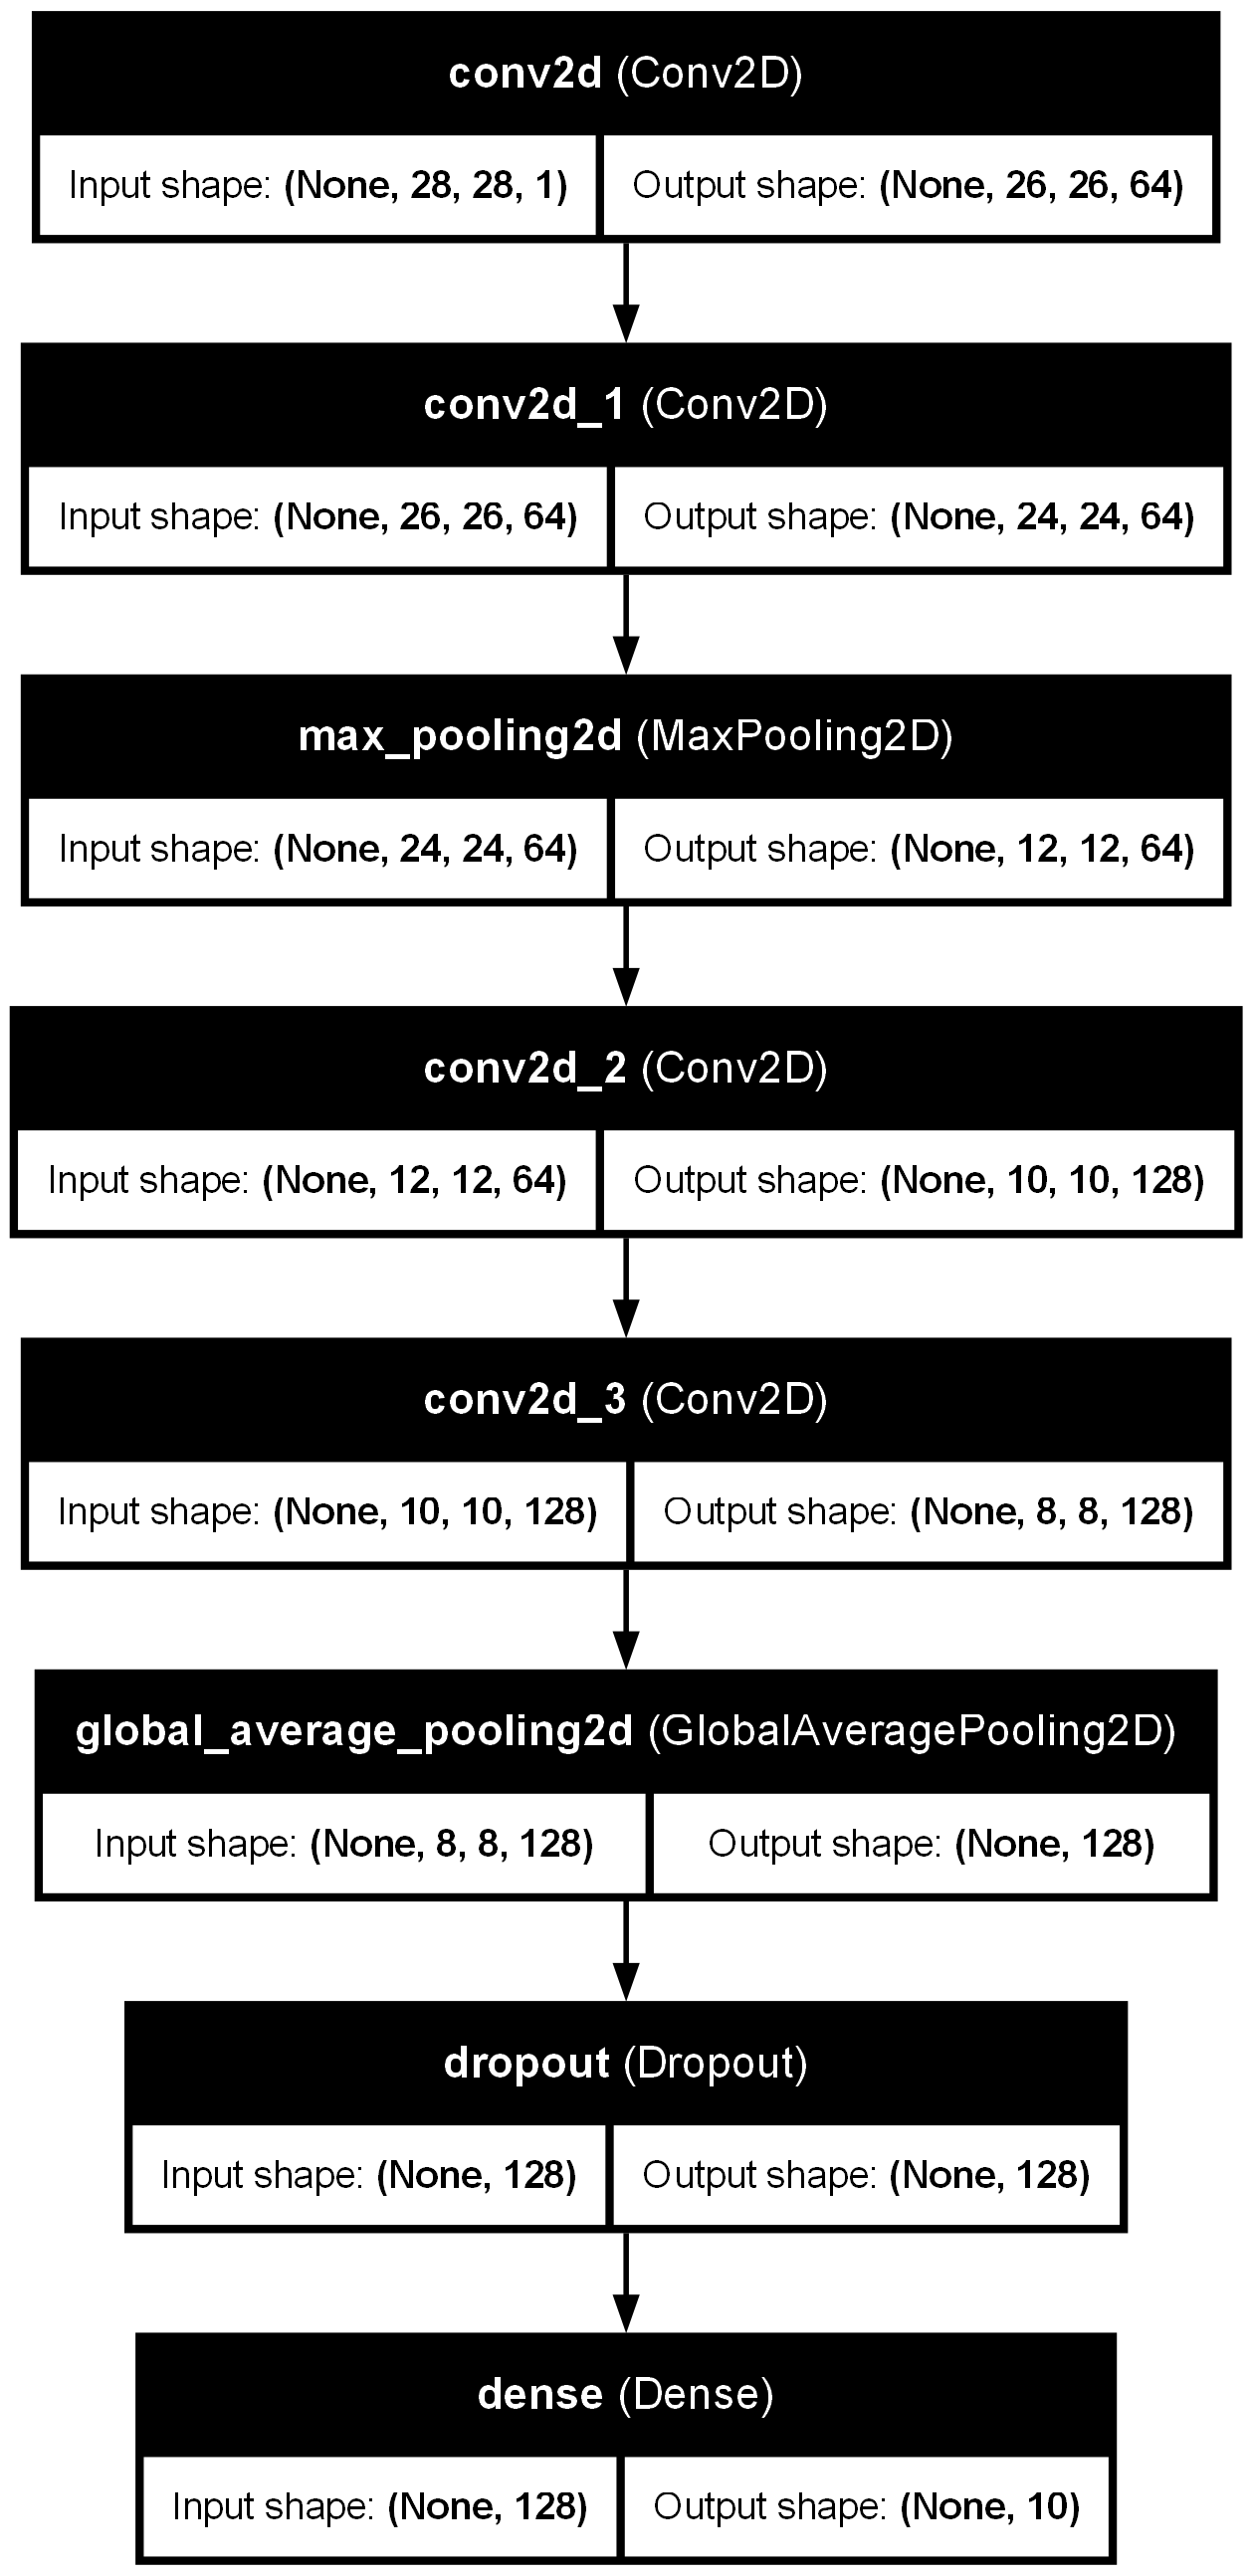

In [ ]:
#from tensorflow.keras.utils import plot_model
#plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

In [13]:
x_train = x_train.values
y_train = y_train.values
x_train = x_train.reshape(x_train.shape[0], 28,28,1)

x_test = x_test.values
y_test = y_test.values
x_test = x_test.reshape(x_test.shape[0], 28,28,1)


print(x_train.shape)
print(y_train.shape)

(60000, 28, 28, 1)
(60000,)


In [14]:

callbacks = [
    #keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2),
]
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
history = model.fit(x_train, y_train, epochs=20, validation_split=0.2, callbacks=callbacks)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - loss: 1.0851 - val_loss: 0.5354
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - loss: 0.5448 - val_loss: 0.4087
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 130s 87ms/step - loss: 0.4558 - val_loss: 0.3662
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 235s 157ms/step - loss: 0.4055 - val_loss: 0.3433
Epoch 5/20
1401/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - loss: 0.3655

KeyboardInterrupt: 

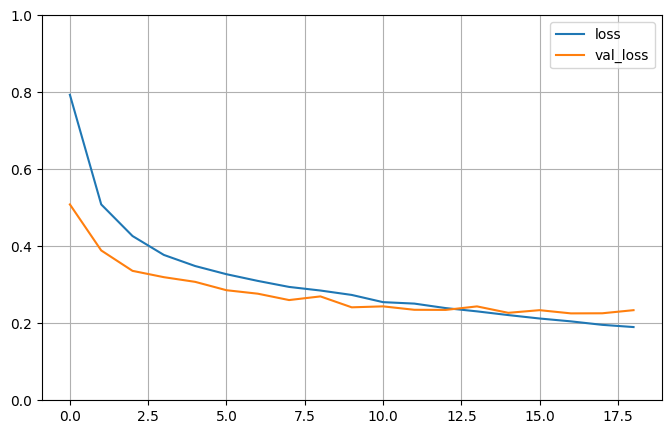

In [10]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [11]:
model.save('saved_mnistCONV.keras')

In [15]:
model = keras.saving.load_model("saved_mnistCONV.keras")

In [16]:
predictions = model.predict(x_test)
predictions[:2]

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step


array([[9.9806398e-01, 8.3757811e-13, 7.0413917e-06, 4.2137901e-05,
        1.6784865e-08, 2.2060938e-08, 1.8868127e-03, 2.2106825e-10,
        1.6990061e-10, 4.5412698e-11],
       [8.5192065e-10, 1.0000000e+00, 3.7479899e-09, 1.0232479e-11,
        7.2025698e-11, 8.1889612e-15, 7.2902279e-10, 1.0266434e-23,
        7.9956990e-14, 2.5120741e-14]], dtype=float32)

In [18]:
predictions.shape

(10000, 10)

In [19]:
predictions = [np.argmax(p) for p in predictions]
predictions[:2]

[np.int64(0), np.int64(1)]

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[869   0  14  12   1   0  93   0  10   1]
 [  0 978   1  12   1   1   6   0   1   0]
 [ 11   0 849  11  42   0  81   0   6   0]
 [ 10   1   4 941  15   0  27   0   1   1]
 [  0   0  15  26 897   0  59   0   3   0]
 [  0   0   0   0   0 980   0  14   1   5]
 [ 93   0  23  19  44   0 817   0   4   0]
 [  0   0   0   0   0   2   0 981   0  17]
 [  2   0   2   0   1   1   2   0 992   0]
 [  0   0   0   0   0   0   0  37   0 963]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1000
           1       1.00      0.98      0.99      1000
           2       0.94      0.85      0.89      1000
           3       0.92      0.94      0.93      1000
           4       0.90      0.90      0.90      1000
           5       1.00      0.98      0.99      1000
           6       0.75      0.82      0.78      1000
           7       0.95      0.98      0.97      1000
           8       0.97      0.99      0.98      1000
           9       0.98     

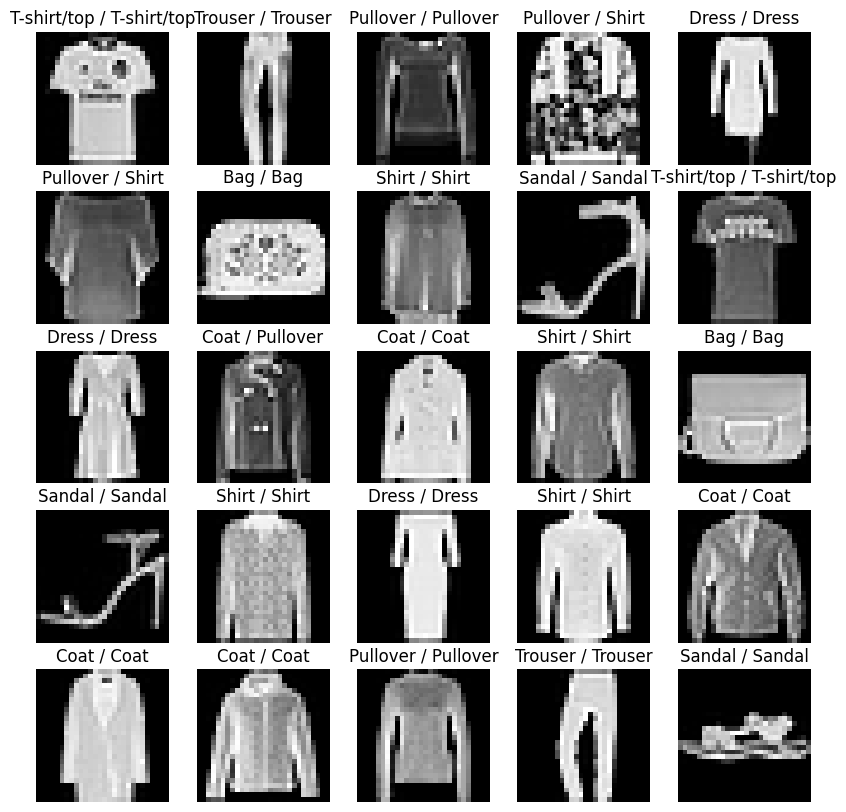

In [21]:

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f'{class_names[y_test[i]]} / {class_names[predictions[i]]}')
    plt.axis('off')
plt.show()

In [17]:
errors = []
for i in range(len(y_test)):
    if y_test[i] != predictions[i]:
        errors.append(i)    
len(errors)

733

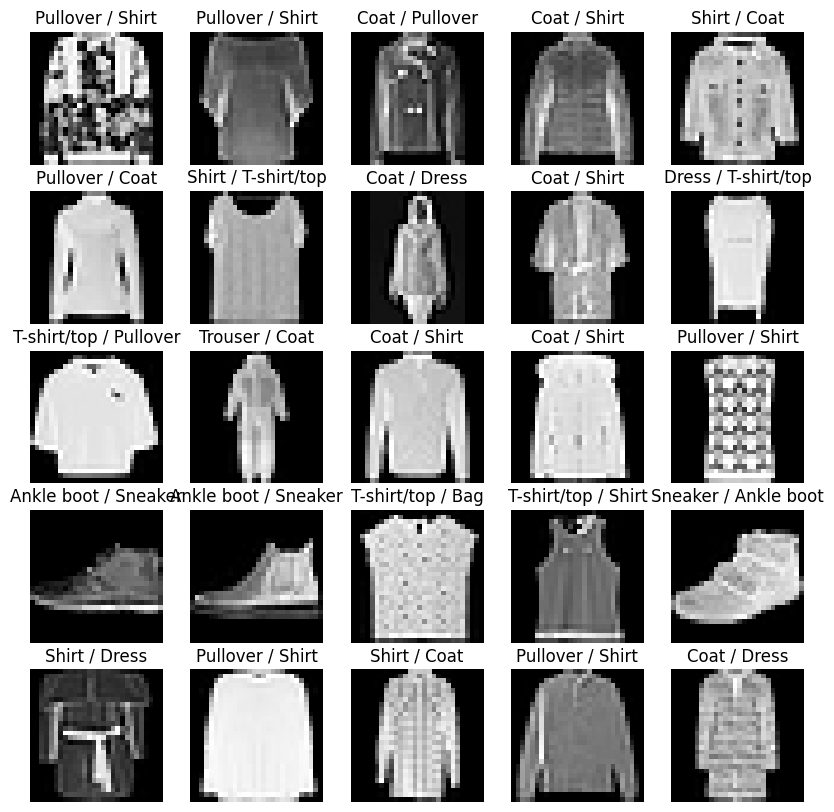

In [18]:
plt.figure(figsize=(10, 10))
for i in range(25):
    
    plt.subplot(5, 5, i+1)
    
    i = errors[i]
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f'{class_names[y_test[i]]} / {class_names[predictions[i]]}')
    plt.axis('off')
plt.show()